This script downloads data using Fido search and then process both HFR and LFR L3 data to produce a combined spectra

In [1]:
import radiospectra.net, pdb
from sunpy.net import Fido, attrs as a
import cdflib,pdb,glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d
from pathlib import Path

/Users/shilpibhunia/mambaforge/envs/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Search both HFR and LFR l3 data in cdaweb using Fido search 

In [3]:
search_date = "2025/03/26"
results = Fido.search(
    a.Time(f"{search_date} 00:00", f"{search_date} 23:59"),(a.cdaweb.Dataset("PSP_FLD_L3_RFS_HFR") |a.cdaweb.Dataset("PSP_FLD_L3_RFS_LFR")
    ))
print(results)

Results from 2 Providers:

1 Results from the CDAWEBClient:
Source: https://cdaweb.gsfc.nasa.gov/index.html

     Dataset              Start time               End time       
------------------ ----------------------- -----------------------
PSP_FLD_L3_RFS_HFR 2025-03-26 00:00:00.000 2025-03-26 23:59:59.000

1 Results from the CDAWEBClient:
Source: https://cdaweb.gsfc.nasa.gov/index.html

     Dataset              Start time               End time       
------------------ ----------------------- -----------------------
PSP_FLD_L3_RFS_LFR 2025-03-26 00:00:01.000 2025-03-26 23:59:57.000




Download the data 

In [5]:
root = "/Users/shilpibhunia/Documents/projects/PSP_analysis/RFS_data/" # path where you want the data folder to be
files = Fido.fetch(results,path=root+"{file}") # will save the files there
print(files)

Files Downloaded: 100%|██████████████████████████████████████████| 2/2 [00:00<00:00,  6.94file/s]

['/Users/shilpibhunia/Documents/projects/PSP_analysis/RFS_data/psp_fld_l3_rfs_hfr_20250326_v03.cdf', '/Users/shilpibhunia/Documents/projects/PSP_analysis/RFS_data/psp_fld_l3_rfs_lfr_20250326_v03.cdf']


Read the data using cdflib

In [9]:
date_tag = search_date.replace("/", "")
hfr_cdf = glob.glob(root + f'*l3_rfs_hfr_{date_tag}*.cdf')[0]
lfr_cdf = glob.glob(root + f'*l3_rfs_lfr_{date_tag}*.cdf')[0]
lfr_file = cdflib.CDF(lfr_cdf)
hfr_file = cdflib.CDF(hfr_cdf)

Get frequency, epoch and spec data for variable rfs_lfr_PSD_SFU and rfs_hfr_PSD_SFU

In [10]:
lfr_var = "psp_fld_l3_rfs_lfr_PSD_SFU"
lfr_attrs = lfr_file.varattsget(lfr_var)
lfr_spec = lfr_file.varget(lfr_var)
lfr_epoch, lfr_freq = (lfr_file.varget(lfr_attrs[k]) for k in ("DEPEND_0", "DEPEND_1"))

hfr_var = "psp_fld_l3_rfs_hfr_PSD_SFU"
hfr_attrs = hfr_file.varattsget(hfr_var)
hfr_spec = hfr_file.varget(hfr_var)
hfr_epoch, hfr_freq = (hfr_file.varget(hfr_attrs[k]) for k in ("DEPEND_0", "DEPEND_1"))


 Convert epochs to numeric time

In [11]:
lfr_time = cdflib.cdfepoch.to_datetime(lfr_epoch)
hfr_time = cdflib.cdfepoch.to_datetime(hfr_epoch)

lfr_time_num = np.array(lfr_time, dtype='datetime64[ns]').astype(float)
hfr_time_num = np.array(hfr_time, dtype='datetime64[ns]').astype(float)


Interpolate HFR onto LFR time grid as both timestamps are not same

In [13]:
hfr_interp = np.stack([interp1d(hfr_time_num,hfr_spec[:, i],kind='linear',bounds_error=False,
        fill_value=np.nan
    )(lfr_time_num)
    for i in range(hfr_spec.shape[1])
], axis=1)

Combine freq and spec

In [14]:
lfreq = lfr_freq[0]
hfreq = hfr_freq[0]
hfr_start_idx = np.argmax(hfreq > lfreq.max())
hfreq_clean = hfreq[hfr_start_idx:]
hfr_interp_clean = hfr_interp[:, hfr_start_idx:]
combined_freq = np.concatenate([lfreq, hfreq_clean])
combined_freq_mhz = combined_freq/1e6 # frequency in MHz
combined_spec = np.concatenate([lfr_spec, hfr_interp_clean], axis=1)

plot the combined spectra

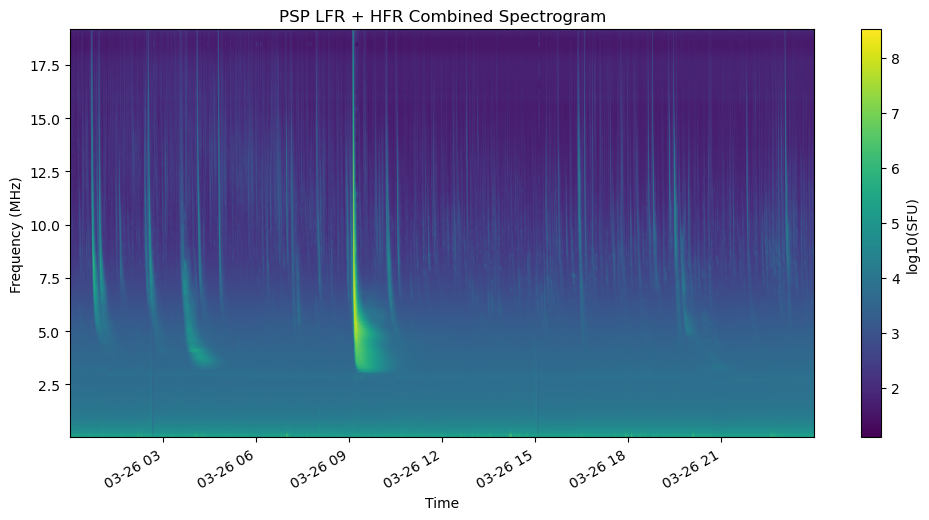

In [15]:
t_num = mdates.date2num(lfr_time)
plt.figure(figsize=(12, 6))
plt.imshow(
    np.log10(combined_spec.T ), 
    aspect='auto',
    origin='lower',
    extent=[t_num[0],t_num[-1],combined_freq_mhz[0],combined_freq_mhz[-1]])

plt.gca().xaxis_date()
plt.gcf().autofmt_xdate()

plt.xlabel("Time")
plt.ylabel("Frequency (MHz)")
plt.title("PSP LFR + HFR Combined Spectrogram")

plt.colorbar(label="log10(SFU)")